In [ ]:
import pandas as pd
data = pd.read_excel('/content/python_data.xlsx', engine = 'openpyxl')
data.head()

/opt/miniconda3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Date,AAPL,IBM,SPY,T30
0,2000-01-31,0.0091,0.0406,-0.0494,0.004343
1,2000-02-29,0.1048,-0.0837,-0.0157,0.004295
2,2000-03-31,0.1848,0.1484,0.0969,0.004377
3,2000-04-28,-0.0865,-0.0551,-0.0351,0.004595
4,2000-05-31,-0.3229,-0.0359,-0.0157,0.004782


In [ ]:
short_lb = 2
long_lb = 4
strat = pd.DataFrame(index=data.index)
strat['Date'] = data['Date']
strat['AAPL_price'] = 100*(1 + data['AAPL']).cumprod()
strat['AAPL_signal'] = 0.0
strat['AAPL_status'] = 0.0
strat.head()

,Date,AAPL_price,AAPL_signal,AAPL_status
0,2000-01-31,100.910000,0.0,0.0
1,2000-02-29,111.485368,0.0,0.0
2,2000-03-31,132.087864,0.0,0.0
3,2000-04-28,120.662264,0.0,0.0
4,2000-05-31,81.700419,0.0,0.0


In [ ]:
strat['AAPL_short_mav'] = strat['AAPL_price'].rolling(window=short_lb, min_periods=1, center=False).mean()
strat['AAPL_long_mav'] = strat['AAPL_price'].rolling(window=long_lb, min_periods=1, center=False).mean()
strat.head()

,Date,AAPL_price,AAPL_signal,AAPL_status,AAPL_short_mav,AAPL_long_mav
0,2000-01-31,100.910000,0.0,0.0,100.910000,100.910000
1,2000-02-29,111.485368,0.0,0.0,106.197684,106.197684
2,2000-03-31,132.087864,0.0,0.0,121.786616,114.827744
3,2000-04-28,120.662264,0.0,0.0,126.375064,116.286374
4,2000-05-31,81.700419,0.0,0.0,101.181341,111.483979


In [ ]:
import numpy as np
strat['AAPL_status'] = np.where(strat['AAPL_short_mav'] > strat['AAPL_long_mav'], 1.0, 0.0)
strat.head()

,Date,AAPL_price,AAPL_signal,AAPL_status,AAPL_short_mav,AAPL_long_mav
0,2000-01-31,100.910000,0.0,0.0,100.910000,100.910000
1,2000-02-29,111.485368,0.0,0.0,106.197684,106.197684
2,2000-03-31,132.087864,0.0,1.0,121.786616,114.827744
3,2000-04-28,120.662264,0.0,1.0,126.375064,116.286374
4,2000-05-31,81.700419,0.0,0.0,101.181341,111.483979


In [ ]:
strat['AAPL_signal'] = strat['AAPL_status'].diff()
strat[strat['AAPL_signal'] == 0.0]

,Date,AAPL_price,AAPL_signal,AAPL_status,AAPL_short_mav,AAPL_long_mav
1,2000-02-29,111.485368,0.0,0.0,106.197684,106.197684
3,2000-04-28,120.662264,0.0,1.0,126.375064,116.286374
5,2000-06-30,101.880422,0.0,0.0,91.790421,109.082742
6,2000-07-31,98.844386,0.0,0.0,100.362404,100.771873
9,2000-10-31,38.058482,0.0,0.0,44.077603,76.385916
...,...,...,...,...,...,...
264,2022-01-31,22217.717138,0.0,1.0,22394.908116,21204.317222
266,2022-03-31,22224.143613,0.0,0.0,21619.941127,22007.424622
267,2022-04-29,20066.179268,0.0,0.0,21145.161441,21380.944665
268,2022-05-31,18972.572498,0.0,0.0,19519.375883,20569.658505


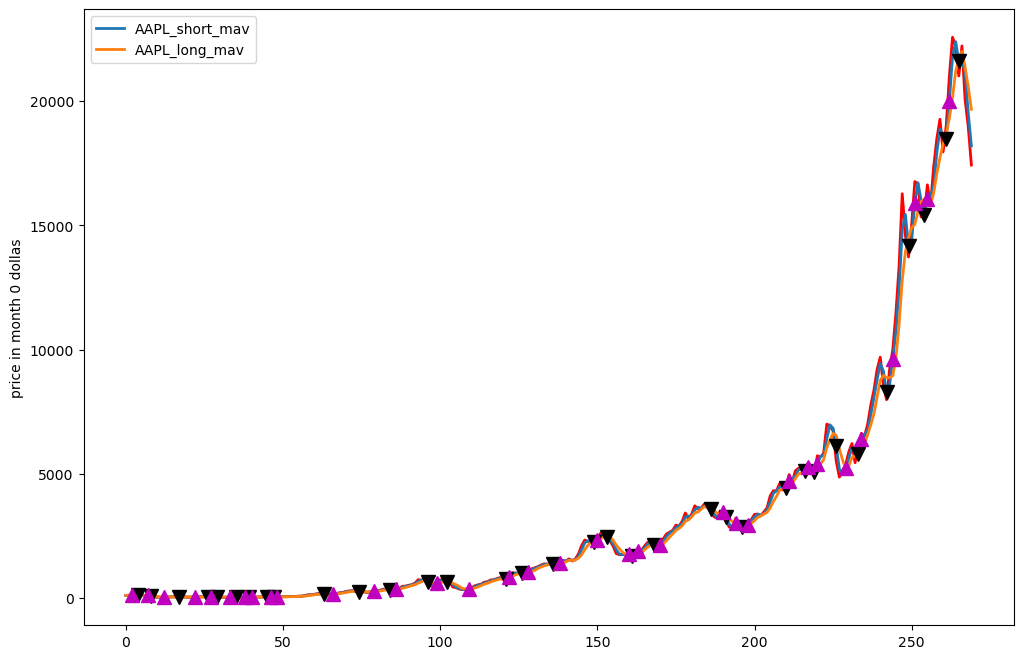

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt1 = fig.add_subplot(111,  ylabel='price in month 0 dollas')
strat['AAPL_price'].plot(ax=plt1, color='r', lw=2.)
strat[['AAPL_short_mav', 'AAPL_long_mav']].plot(ax=plt1, lw=2., figsize=(12,8))
plt1.plot(strat.loc[strat.AAPL_signal == -1.0].index,strat.AAPL_short_mav[strat.AAPL_signal == -1.0],'v',markersize=10, color='k')
plt1.plot(strat.loc[strat.AAPL_signal == 1.0].index,strat.AAPL_short_mav[strat.AAPL_signal == 1.0],'^',markersize=10, color='m')